<a href="https://colab.research.google.com/github/ShuimuZeng/first/blob/main/DLT_CW2_code_for_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Import and Setup

In [30]:
#import necessary libraries
import os
import random
import time
import shutil
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import math
import torch
from torch import nn
import torch.utils.data
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
# !pip install --upgrade sympy
#Set up and Ensure reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything()

2.Configuration and device setup

In [31]:
# Configuration
class opt:
    batch_size = 64
    workers = 2
    lr = 0.001
    normal_train_path = "normal_train.csv"
    normal_valid_path = "normal_valid.csv"
    patient_valid_path = "patient_valid.csv"
    # Set device configuration
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de: {device}")

Utilisation de: cpu


3. Data Preparation

Shape du DataFrame : (4998, 141)


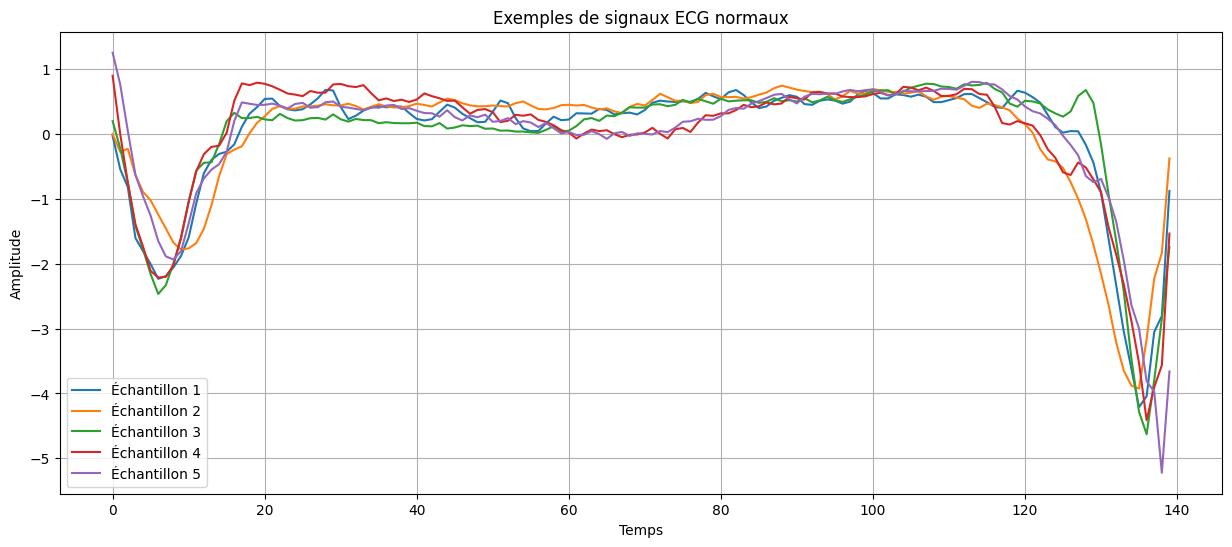

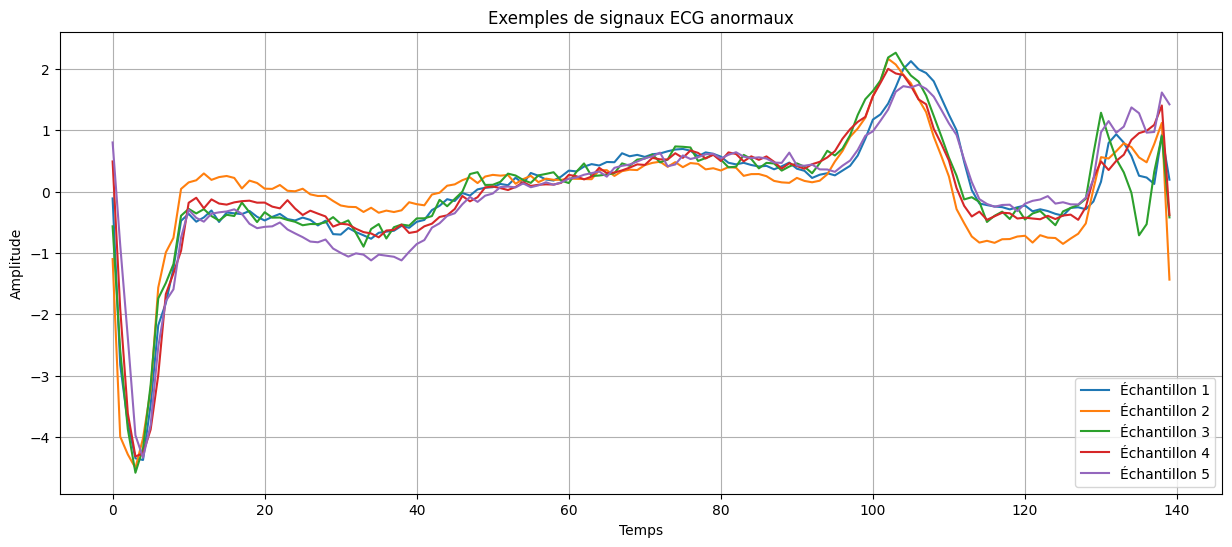

In [33]:
# link for the dataset
url = "http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv"
local_path = "ecg.csv"
# choose between local path or url download
if not os.path.exists(local_path):
    print("Téléchargement du fichier ECG...")
    urllib.request.urlretrieve(url, local_path)
    # load the dataset, it seems that the dataset has no header
df = pd.read_csv(local_path, header=None)
print("Shape du DataFrame :", df.shape)
# Adapter dynamiquement les noms de colonnes
num_cols = df.shape[1]
df.columns = list(range(num_cols - 1)) + ['target']  # dernière colonne = étiquette
# df.columns
# Filter the target to create dataframe for normal people and for patient
#We filter the instance with 0 as target then we get normal peoples
df_normal = df[df['target'] == 0].reset_index(drop=True)
df_patient = df[df['target'] == 1].reset_index(drop=True)
# split the dataset to training set and validation set
df_train, df_val = train_test_split(df_normal, test_size=0.2, random_state=42)
# write dataset to csv files
df_train.to_csv("normal_train.csv", index=False, header=False)
df_val.to_csv("normal_valid.csv", index=False, header=False)
df_patient.to_csv("patient_valid.csv", index=False, header=False)

# Visualisation for ECG signals
def plot_ecg_sample(dataframe, title, n_samples=5):
    plt.figure(figsize=(15, 6))
    # Prendre les colonnes de données, sans la cible
    for i in range(n_samples):
        signal = dataframe.iloc[i, :-1].values.astype(float)
        plt.plot(signal, label=f"Échantillon {i+1}")
    plt.title(title)
    plt.xlabel("Temps")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

# Affichage de quelques signaux normaux et anormaux
plot_ecg_sample(df_normal, "Exemples de signaux ECG normaux")
# plot_ecg_sample(df_patient, "Exemples de signaux ECG anormaux")

plot_ecg_sample(df_patient, "Exemples de signaux ECG anormaux")

4.Datasets and Dataloaders

In [ ]:
# Classe Dataset adaptée au format de données
class ECGDataset(torch.utils.data.Dataset):
    def __init__(self, path):
        self.data = pd.read_csv(path, header=None)
        # Le nombre de features est le nombre de colonnes - 1 (sans la cible)
        self.num_features = self.data.shape[1] - 1

    def __getitem__(self, idx):
        # Prendre toutes les colonnes sauf la dernière (qui est la cible)
        x = self.data.iloc[idx, :self.num_features].values.astype(np.float32)
        return torch.tensor(x)

    def __len__(self):
        return len(self.data)

# Classe de test adaptée au format de données
class ECGTestDataset(torch.utils.data.Dataset):
    def __init__(self, path, is_normal=True):
        self.data = pd.read_csv(path, header=None)

        # Déterminer automatiquement le nombre de colonnes
        num_cols = self.data.shape[1]

        if num_cols == 141:  # Format TensorFlow (140 caractéristiques + 1 étiquette)
            # Si is_normal=True, on garde les données normales, sinon les anormales
            if is_normal:
                # Pour les données normales (target=0)
                self.data = self.data[self.data[num_cols-1] == 0].values[:, :num_cols-1]
            else:
                # Pour les données anormales (target=1)
                self.data = self.data[self.data[num_cols-1] == 1].values[:, :num_cols-1]

        print(f"Dataset shape: {self.data.shape}")

    def __getitem__(self, idx):
        # Renvoyer toutes les caractéristiques (sans l'étiquette)
        x = self.data[idx]
        return torch.tensor(x, dtype=torch.float32)

    def __len__(self):
        return len(self.data)


# Chargeurs de données pour l'entraînement et la validation
normal_train_dset = ECGDataset(opt.normal_train_path)
trainloader = DataLoader(
    normal_train_dset,
    batch_size=opt.batch_size,
    shuffle=True,
    num_workers=opt.workers
)

In [ ]:
# ===== LSTM AutoEncoder =====
class LSTMEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_size = 64
        self.lstm1 = nn.LSTMCell(1, self.hidden_size)
        self.lstm2 = nn.LSTMCell(1, self.hidden_size)
        self.linear = nn.Linear(self.hidden_size, 1)
        self.seq_len = None  # Sera défini dynamiquement

    def Encoder(self, inp):
        # Stocker la longueur de séquence pour le décodeur
        self.seq_len = inp.size(1)

        ht = torch.zeros(inp.size(0), self.hidden_size, device=device)
        ct = torch.zeros(inp.size(0), self.hidden_size, device=device)
        for input_t in inp.chunk(inp.size(1), dim=1):
            ht, ct = self.lstm1(input_t, (ht, ct))
        return ht, ct

    def Decoder(self, ht, ct):
        ot = torch.zeros(ht.size(0), 1, device=device)
        outputs = torch.zeros(ht.size(0), self.seq_len, device=device)
        for i in range(self.seq_len):
            ht, ct = self.lstm2(ot, (ht, ct))
            ot = self.linear(ht)
            outputs[:, i] = ot.squeeze()
        return outputs

    def forward(self, inp):
        he, ce = self.Encoder(inp)
        out = self.Decoder(he, ce)
        return torch.flip(out, dims=[1])

In [ ]:
# class LSTMSeq2Seq(nn.Module):
#     def __init__(self, input_size=1, hidden_size=64, output_size=1):
#         super(LSTMSeq2Seq, self).__init__()
#         self.hidden_size = hidden_size

#         # Encoder
#         self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)

#         # Decoder
#         self.decoder = nn.LSTM(hidden_size, hidden_size, batch_first=True)
#         self.fc = nn.Linear(hidden_size, output_size)

#     def forward(self, x):
#         # Reshape input to (batch_size, seq_len, input_size)
#         x = x.view(x.size(0), x.size(1), 1)  # Reshape to (64, 140, 1)

#         # Encoder
#         encoder_output, (hidden, cell) = self.encoder(x)

#         # Decoder
#         decoder_input = torch.zeros(x.size(0), x.size(1), self.hidden_size, device=x.device)  # Initialize decoder input
#         decoder_output, _ = self.decoder(decoder_input, (hidden, cell))

#         # Output
#         output = self.fc(decoder_output[:, -1, :])  # Take the last decoder output
#         output = output.repeat(1, x.size(1))  # Repeat the output to match input length

#         return output

# class LSTMSeq2SeqAttention(nn.Module):
#     def __init__(self, input_size=1, hidden_size=64, output_size=1):
#         super(LSTMSeq2SeqAttention, self).__init__()
#         self.hidden_size = hidden_size

#         # Encoder
#         self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)

#         # Attention Mechanism
#         self.attn = nn.Linear(hidden_size * 2, hidden_size)  # Attention layer
#         self.v = nn.Parameter(torch.rand(hidden_size))  # Attention vector

#         # Decoder
#         self.decoder = nn.LSTM(hidden_size, hidden_size, batch_first=True)
#         self.fc = nn.Linear(hidden_size, output_size)

#     def forward(self, x):
#         # Reshape input
#         x = x.view(x.size(0), x.size(1), 1)  # Reshape to (64, 140, 1)

#         # Encoder
#         encoder_outputs, (hidden, cell) = self.encoder(x)

#         # Decoder
#         decoder_input = torch.zeros(x.size(0), 1, self.hidden_size, device=x.device)  # Initial decoder input
#         outputs = torch.zeros(x.size(0), x.size(1), 1, device=x.device)  # Output tensor

#         for t in range(x.size(1)):
#             # Calculate attention weights
#             attn_weights = self.calculate_attention(hidden, encoder_outputs)

#             # Apply attention to encoder outputs
#             context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)

#             # Decoder step
#             decoder_output, (hidden, cell) = self.decoder(decoder_input, (hidden, cell))

#             # Output
#             output = self.fc(decoder_output[:, -1, :])  # Take the last output
#             outputs[:, t, :] = output  # Store output for current timestep

#             # Update decoder input for next timestep
#             decoder_input = context.unsqueeze(1)

#         return outputs.squeeze(2)  # Reshape to (64, 140)

#     def calculate_attention(self, hidden, encoder_outputs):
#         # Calculate attention scores
#         hidden_with_time_axis = hidden.repeat(1, encoder_outputs.size(1), 1)
#         attn_hidden = torch.tanh(self.attn(torch.cat((hidden_with_time_axis, encoder_outputs), 2)))

#         # Calculate attention weights
#         attn_weights = torch.bmm(attn_hidden, self.v.unsqueeze(1).unsqueeze(0)).squeeze(2)
#         attn_weights = F.softmax(attn_weights, dim=1)

#         return attn_weights

In [ ]:
# class LSTMEncoderAtt(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.hidden_size = 64
#         self.lstm1 = nn.LSTMCell(1, self.hidden_size)
#         self.lstm2 = nn.LSTMCell(1, self.hidden_size)
#         self.linear = nn.Linear(self.hidden_size, 1)
#         self.seq_len = None  # Sera défini dynamiquement
#         # Attention mechanism
#         self.attn = nn.Linear(self.hidden_size * 2, self.seq_len)
#         self.attn_combine = nn.Linear(self.hidden_size * 2, self.hidden_size)

#     def Encoder(self, inp):
#         # Stocker la longueur de séquence pour le décodeur
#         self.seq_len = inp.size(1)

#         ht = torch.zeros(inp.size(0), self.hidden_size, device=device)
#         ct = torch.zeros(inp.size(0), self.hidden_size, device=device)
#         encoder_outputs = torch.zeros(inp.size(0), self.seq_len, self.hidden_size, device=device)
#         for i, input_t in enumerate(inp.chunk(inp.size(1), dim=1)):
#             ht, ct = self.lstm1(input_t, (ht, ct))
#             encoder_outputs[:, i, :] = ht  # Store encoder outputs for attention
#         return ht, ct, encoder_outputs

#     def Decoder(self, ht, ct, encoder_outputs):
#         ot = torch.zeros(ht.size(0), 1, device=device)
#         outputs = torch.zeros(ht.size(0), self.seq_len, device=device)
#         for i in range(self.seq_len):
#             # Apply attention mechanism
#             attn_weights = F.softmax(self.attn(torch.cat((ot, ht), 1)), dim=1)
#             attn_applied = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
#             ht = self.attn_combine(torch.cat((ot, attn_applied), 1))

#             ht, ct = self.lstm2(ot, (ht, ct))  # Use the modified hidden state
#             ot = self.linear(ht)
#             outputs[:, i] = ot.squeeze()
#         return outputs

#     def forward(self, inp):
#         he, ce, encoder_outputs = self.Encoder(inp)
#         out = self.Decoder(he, ce, encoder_outputs)
#         return torch.flip(out, dims=[1])

class LSTMAutoEncoderWithAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_size = 64
        self.lstm1 = nn.LSTMCell(1, self.hidden_size)
        self.lstm2 = nn.LSTMCell(self.hidden_size + 1, self.hidden_size)  # context + previous output
        self.linear = nn.Linear(self.hidden_size, 1)
        self.seq_len = None

    def Encoder(self, inp):
        self.seq_len = inp.size(1)
        batch_size = inp.size(0)

        ht = torch.zeros(batch_size, self.hidden_size, device=device)
        ct = torch.zeros(batch_size, self.hidden_size, device=device)
        encoder_outputs = []

        for input_t in inp.chunk(self.seq_len, dim=1):
            ht, ct = self.lstm1(input_t, (ht, ct))
            encoder_outputs.append(ht.unsqueeze(1))  # shape: (batch, 1, hidden)

        encoder_outputs = torch.cat(encoder_outputs, dim=1)  # (batch, seq_len, hidden)
        return encoder_outputs, ht, ct

    def compute_attention(self, decoder_hidden, encoder_outputs):
        # decoder_hidden: (batch, hidden)
        # encoder_outputs: (batch, seq_len, hidden)
        attn_scores = torch.bmm(encoder_outputs, decoder_hidden.unsqueeze(2)).squeeze(2)  # (batch, seq_len)
        attn_weights = F.softmax(attn_scores, dim=1)  # (batch, seq_len)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # (batch, hidden)
        return context, attn_weights

    def Decoder(self, encoder_outputs, ht, ct):
        ot = torch.zeros(ht.size(0), 1, device=device)
        outputs = torch.zeros(ht.size(0), self.seq_len, device=device)

        for i in range(self.seq_len):
            context, _ = self.compute_attention(ht, encoder_outputs)  # (batch, hidden)
            dec_input = torch.cat([ot, context], dim=1)  # (batch, hidden + 1)
            ht, ct = self.lstm2(dec_input, (ht, ct))
            ot = self.linear(ht)
            outputs[:, i] = ot.squeeze()

        return outputs

    def forward(self, inp):
        encoder_outputs, he, ce = self.Encoder(inp)
        out = self.Decoder(encoder_outputs, he, ce)
        return torch.flip(out, dims=[1])

In [ ]:
class CNNAutoencoder(nn.Module):
    def __init__(self, input_size=140):
        super(CNNAutoencoder, self).__init__()
        self.input_size = input_size

        # Encodeur
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.ReLU()
        )

        # Calculer la taille après convolutions
        self.encoded_size = input_size // 8
        if self.encoded_size <= 0:
            self.encoded_size = 1

        # Décodeur
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 1, kernel_size=5, stride=2, padding=2, output_padding=1)
        )

    def forward(self, x):
        # Reshape pour CNN (batch, channels, length)
        x_original = x  # Sauvegarde de l'entrée originale
        x = x.unsqueeze(1)  # Ajoute une dimension de canal

        # Encodage-décodage
        x = self.encoder(x)
        x = self.decoder(x)

        # Redimensionner la sortie pour qu'elle corresponde exactement à l'entrée originale
        x = x.squeeze(1)  # Enlève la dimension de canal

        # Si les dimensions ne correspondent pas, redimensionner
        if x.size(1) != self.input_size:
            x = F.interpolate(x.unsqueeze(1), size=self.input_size, mode='linear', align_corners=False).squeeze(1)

        return x

In [ ]:
# ===== GRU AutoEncoder =====
class GRUEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_size = 64
        self.gru1 = nn.GRUCell(1, self.hidden_size)  # GRUCell for encoder
        self.gru2 = nn.GRUCell(1, self.hidden_size)  # GRUCell for decoder
        self.linear = nn.Linear(self.hidden_size, 1)
        self.seq_len = None

    def Encoder(self, inp):
        self.seq_len = inp.size(1)
        ht = torch.zeros(inp.size(0), self.hidden_size, device=device)
        for input_t in inp.chunk(inp.size(1), dim=1):
            ht = self.gru1(input_t, ht)  # Update hidden state for GRU
        return ht

    def Decoder(self, ht):
        ot = torch.zeros(ht.size(0), 1, device=device)
        outputs = torch.zeros(ht.size(0), self.seq_len, device=device)
        for i in range(self.seq_len):
            ht = self.gru2(ot, ht)  # Update hidden state for GRU
            ot = self.linear(ht)
            outputs[:, i] = ot.squeeze()
        return outputs

    def forward(self, inp):
        he = self.Encoder(inp)
        out = self.Decoder(he)
        return torch.flip(out, dims=[1])

In [ ]:
#stacked GRU
class GRUEncoderstacked(nn.Module):
    def __init__(self, num_layers=2):  # Add num_layers argument
        super().__init__()
        self.hidden_size = 64
        self.num_layers = num_layers  # Store num_layers
        self.gru_layers = nn.ModuleList([nn.GRUCell(1 if i == 0 else self.hidden_size, self.hidden_size)
                                        for i in range(self.num_layers)])  # Create GRU layers
        self.gru2 = nn.GRUCell(1, self.hidden_size)  # GRUCell for decoder (unchanged)
        self.linear = nn.Linear(self.hidden_size, 1)
        self.seq_len = None

    def Encoder(self, inp):
        self.seq_len = inp.size(1)
        hidden_states = [torch.zeros(inp.size(0), self.hidden_size, device=device)
                         for _ in range(self.num_layers)]  # Initialize hidden states for all layers
        for input_t in inp.chunk(inp.size(1), dim=1):
            for i, gru_layer in enumerate(self.gru_layers):
                hidden_states[i] = gru_layer(input_t if i == 0 else hidden_states[i-1], hidden_states[i])
                # Input to first layer is the input sequence, subsequent layers use previous layer's output
                input_t = hidden_states[i]
        return hidden_states[-1] # Output only the hidden state of the last layer

    def Decoder(self, ht):
        # ... (decoder remains the same) ...
        ot = torch.zeros(ht.size(0), 1, device=device)
        outputs = torch.zeros(ht.size(0), self.seq_len, device=device)
        for i in range(self.seq_len):
            ht = self.gru2(ot, ht)  # Update hidden state for GRU
            ot = self.linear(ht)
            outputs[:, i] = ot.squeeze()
        return outputs

    def forward(self, inp):
        # ... (forward method remains the same) ...
        he = self.Encoder(inp)
        out = self.Decoder(he)
        return torch.flip(out, dims=[1])

In [ ]:
# VAE model
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.mu = nn.Linear(32, latent_dim)
        self.logvar = nn.Linear(32, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

In [ ]:
models = {
    # "VAE": VAE(input_dim=140, latent_dim=64),
    "CNN": CNNAutoencoder(),
    "GRU": GRUEncoder(),
    "LSTM": LSTMEncoder(),
    "VAE": VAE(input_dim=140, latent_dim=64),
    # "VAE": VAE(input_dim=140, latent_dim=64),
    # "VAE": GRUEncoder(),
    # "LSTM+Att": LSTMEncoderAtt(),#this one is still on the way
    # "LSTMSEQ2SRQ": LSTMSeq2Seq(),

    # "LSTMSEQ2SEQATT": LSTMSeq2SeqAttention(),
    # "LSTM+Att": LSTMAutoEncoderWithAttention(),

    # "GRU+Att": GRUEncoder(),
    # "CNN": CNNEncoderDecoder(),

    # "CNN": CNNEncoderDecoder(),
    # "GRUSTACKED": GRUEncoderstacked(),
    # "LSTM": LSTMEncoder(),
    # "GRU": GRUEncoder(),

    # "KL+LSTM": KLLSTMEncoder(),
    # "MLP": MLPAutoencoder(),
    # "KL+MLP": KLMLPAutoencoder()
}

In [ ]:
# Fonctions de perte
def loss_function(pred, real):
    mse = F.mse_loss(pred, real, reduction="sum")
    return mse

In [ ]:
# Loss function for VAE
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + kl_div

In [ ]:
# Fonction de visualisation des reconstructions
def plot_reconstruction(model, name, n_samples=5):
    model.eval()
    samples = next(iter(trainloader))[:n_samples].to(device)
    # print(samples.shape)
    with torch.no_grad():
        output = model(samples)
        if isinstance(output, tuple):
            output = output[0]

    samples = samples.cpu().numpy()
    output = output.cpu().numpy()
    # print(output.shape)
    # print(output)

    plt.figure(figsize=(15, n_samples * 2))
    for i in range(n_samples):
        plt.subplot(n_samples, 2, 2 * i + 1)
        plt.plot(samples[i], label="Original")
        plt.title(f"{name} - Original Signal {i+1}")
        plt.grid(True)
        plt.subplot(n_samples, 2, 2 * i + 2)
        plt.plot(output[i], label="Reconstruit", color="orange")
        plt.title(f"{name} - Reconstruction {i+1}")
        plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{name}_reconstructions.png")
    plt.show()


🔁 Entraînement du modèle : CNN
Epoch 1/50 - Loss: 56.9882
Epoch 2/50 - Loss: 10.2041
Epoch 3/50 - Loss: 4.5888
Epoch 4/50 - Loss: 2.7370
Epoch 5/50 - Loss: 2.1257
Epoch 6/50 - Loss: 1.8099
Epoch 7/50 - Loss: 1.6800
Epoch 8/50 - Loss: 1.5335
Epoch 9/50 - Loss: 1.3847
Epoch 10/50 - Loss: 1.3149
Epoch 11/50 - Loss: 1.2729
Epoch 12/50 - Loss: 1.1726
Epoch 13/50 - Loss: 1.1168
Epoch 14/50 - Loss: 1.0689
Epoch 15/50 - Loss: 1.0604
Epoch 16/50 - Loss: 0.9621
Epoch 17/50 - Loss: 0.9114
Epoch 18/50 - Loss: 0.8838
Epoch 19/50 - Loss: 0.9117
Epoch 20/50 - Loss: 0.8429
Epoch 21/50 - Loss: 0.8411
Epoch 22/50 - Loss: 0.8127
Epoch 23/50 - Loss: 0.7648
Epoch 24/50 - Loss: 0.7521
Epoch 25/50 - Loss: 0.7219
Epoch 26/50 - Loss: 0.7053
Epoch 27/50 - Loss: 0.6813
Epoch 28/50 - Loss: 0.6709
Epoch 29/50 - Loss: 0.6738
Epoch 30/50 - Loss: 0.6280
Epoch 31/50 - Loss: 0.5934
Epoch 32/50 - Loss: 0.5914
Epoch 33/50 - Loss: 0.5467
Epoch 34/50 - Loss: 0.5406
Epoch 35/50 - Loss: 0.5241
Epoch 36/50 - Loss: 0.5214
Epo

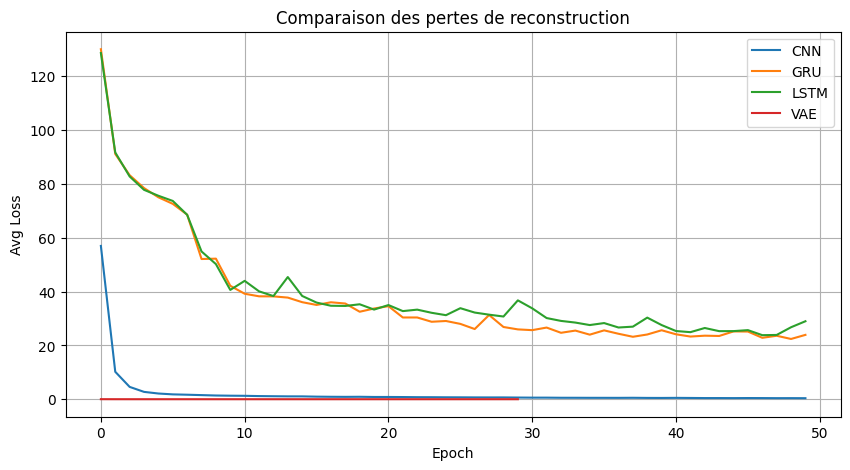

In [ ]:
results = {}
for name, model in models.items():
    print(f"\n🔁 Entraînement du modèle : {name}")
    model.to(device)
    model.train()
    # Si c'est un modèle MLP, initialise-le avec un batch vide
    if "MLP" in name:
        # Obtenir un batch d'exemple pour initialiser les couches
        sample_batch = next(iter(trainloader))
        # Passe forward pour initialiser les couches
        _ = model(sample_batch.to(device))
    use_kl = "KL" in name.upper()
    # criterion = loss_function_kl if use_kl else loss_function
    criterion = loss_function
    if name in ["LSTM", "KL+LSTM","GRU","CNN","GRUSTACKED"]:
        epochs = 50
    else:
        criterion = vae_loss
        epochs = 30
    optimizer = torch.optim.Adam(model.parameters(), lr=opt.lr)
    if name == "VAE":
        epoch_losses = []
        for epoch in range(epochs):
          total_loss = 0
          for batch in trainloader:
            batch = batch.to(device)
            optimizer.zero_grad()
            # output = model(batch)
            recon_batch, mu, logvar = model(batch)
            loss = criterion(recon_batch, batch, mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

          avg_loss = total_loss / len(trainloader.dataset)
          epoch_losses.append(avg_loss)
          print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")
        results[name] = {"losses": epoch_losses, "model": model}
        break
    epoch_losses = []
    for epoch in range(epochs):
        total_loss = 0
        for batch in trainloader:
            batch = batch.to(device)
            optimizer.zero_grad()
            output = model(batch)
            loss = criterion(output, batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(trainloader.dataset)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")
    results[name] = {"losses": epoch_losses, "model": model}

# Affichage des courbes de perte
plt.figure(figsize=(10, 5))
for name in results:
    plt.plot(results[name]["losses"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Avg Loss")
plt.title("Comparaison des pertes de reconstruction")
plt.legend()
plt.grid(True)
plt.savefig("training_loss_comparison.png")
plt.show()


📉 Reconstruction avec VAE


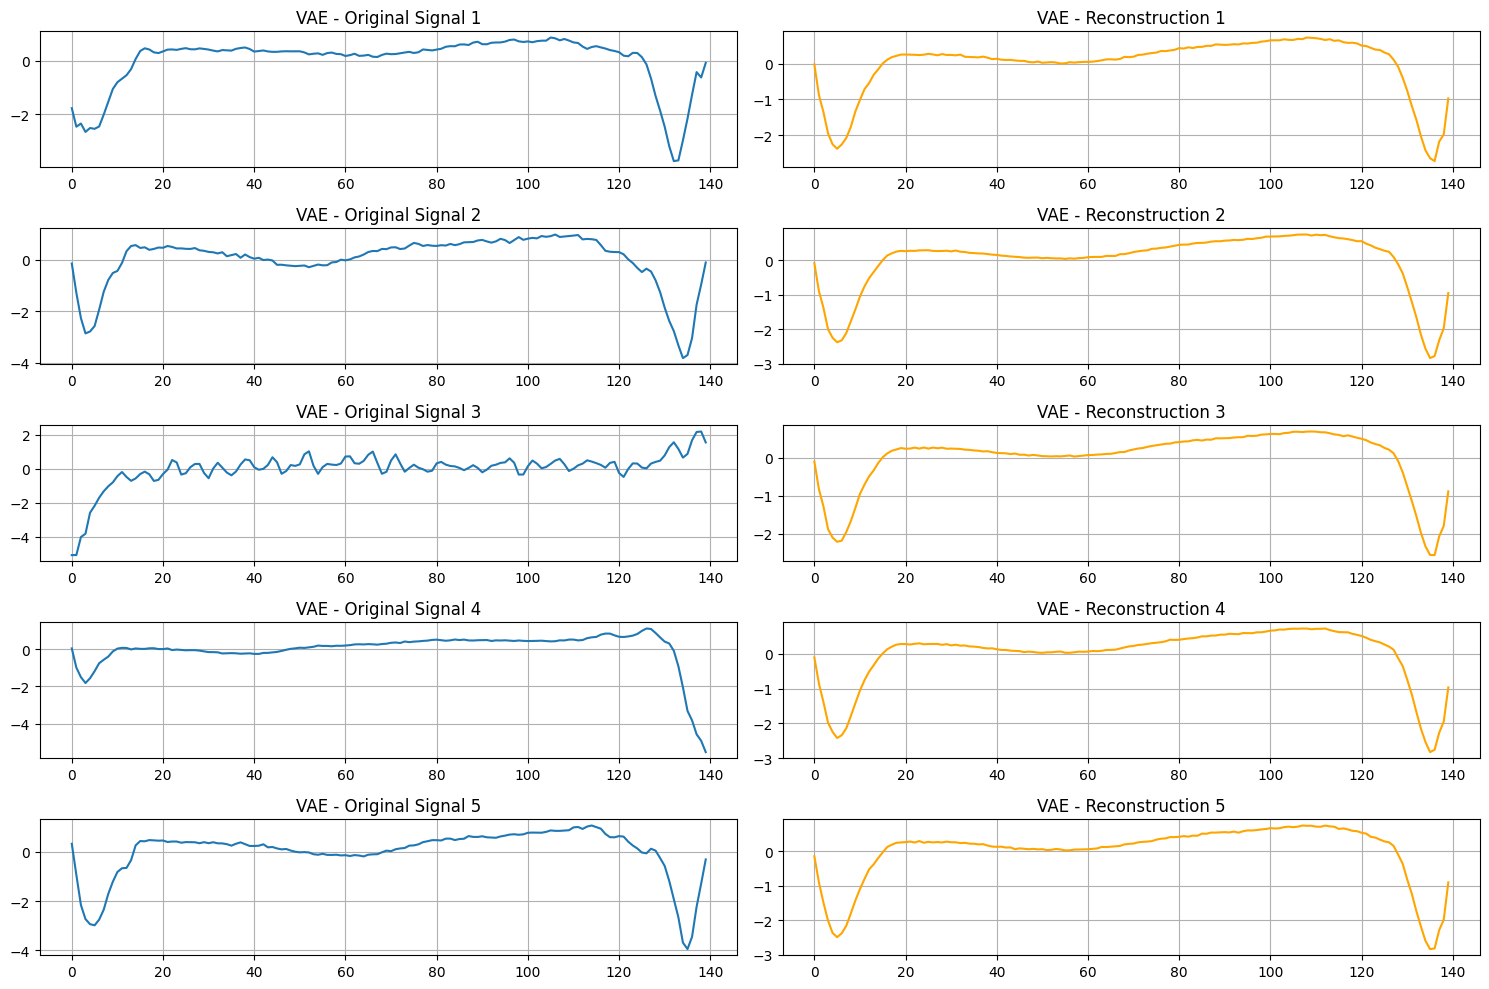

In [ ]:
# Visualisation pour chaque modèle
for name in results:
    print(f"\n📉 Reconstruction avec {name}")
    plot_reconstruction(results[name]["model"], name)

In [ ]:
# Fonction d'évaluation pour la détection d'anomalies
def evaluate_anomaly_detection(models, testloader, validloader, device):
    """
    Évalue la capacité de détection d'anomalies des modèles en utilisant
    l'erreur de reconstruction comme score d'anomalie.

    Args:
        models: Dictionnaire des modèles à évaluer
        testloader: DataLoader des données normales (testloader)
        validloader: DataLoader des données anormales (validloader)
        device: Dispositif pour les calculs (CPU/GPU)

    Returns:
        Un dictionnaire contenant les résultats d'évaluation pour chaque modèle
    """
    results = {}

    for name, model in models.items():
        print(f"\n==== Évaluation du modèle: {name} ====")
        model.eval()

        # Fonction pour calculer les pertes sur un ensemble de données
        def get_loss(loader, model):
            total_loss = []
            samples = []
            reconstructions = []

            with torch.no_grad():
                for signal in loader:
                    # Assurer que le signal est sur le bon device et en float32
                    signal = signal.to(device).float()

                    # Gérer les différentes sorties des modèles (KL vs non-KL)
                    output = model(signal)
                    if isinstance(output, tuple):
                        output = output[0]

                    # Calculer MSE
                    loss = F.mse_loss(output, signal, reduction="sum") / signal.size(0)
                    total_loss.append(loss.item())

                    # Stocker quelques échantillons pour visualisation
                    if len(samples) < 5:
                        samples.append(signal[0].cpu().numpy())
                        reconstructions.append(output[0].cpu().numpy())

            return np.array(total_loss), samples, reconstructions

        # Obtenir les pertes pour les données normales et anormales
        test_loss, normal_samples, reconstructed_normal = get_loss(testloader, model)
        valid_loss, abnormal_samples, reconstructed_abnormal = get_loss(validloader, model)

        # Trouver les valeurs min/max pour la normalisation
        maxl = max(test_loss.max(), valid_loss.max())
        minl = min(test_loss.min(), valid_loss.min())

        # Normaliser les pertes
        def normalize_loss(loss):
            return (loss - minl) / (maxl - minl)

        test_loss_norm = normalize_loss(test_loss)
        valid_loss_norm = normalize_loss(valid_loss)

        # Créer les labels (0 pour normal, 1 pour anomalie)
        y_true = np.concatenate([np.zeros_like(test_loss_norm), np.ones_like(valid_loss_norm)])
        # Concaténer les scores (erreurs) pour les deux classes
        scores = np.concatenate([test_loss_norm, valid_loss_norm])

        # Calculer l'AUC-ROC
        fpr, tpr, thresholds_roc = roc_curve(y_true, scores)
        roc_auc = auc(fpr, tpr)

        # Trouver le seuil optimal (F1 maximum)
        def find_optimal_threshold(test_loss, valid_loss):
            optimal_threshold = 0
            optimal_fscore = 0

            for threshold in np.arange(0, 1, 0.01):
                normal_pred = []
                for x in test_loss:
                    pred = 1 if x > threshold else 0
                    normal_pred.append(pred)

                patient_pred = []
                for x in valid_loss:
                    pred = 1 if x > threshold else 0
                    patient_pred.append(pred)

                normal_pred = np.array(normal_pred)
                patient_pred = np.array(patient_pred)

                tp = sum(patient_pred)
                fp = sum(normal_pred)

                if tp + fp == 0:  # Éviter division par zéro
                    continue

                precision = tp / (tp + fp)

                if tp == 0:  # Éviter division par zéro
                    continue

                recall = tp / len(patient_pred)

                if precision + recall == 0:  # Éviter division par zéro
                    continue

                fscore = (2 * precision * recall) / (precision + recall)

                if fscore > optimal_fscore:
                    optimal_fscore = fscore
                    optimal_threshold = threshold

            return optimal_threshold

        optimal_threshold = find_optimal_threshold(test_loss_norm, valid_loss_norm)

        # Calculer les métriques avec le seuil optimal
        def print_metrics(test_loss, valid_loss, threshold, beta=1):
            normal_pred = []
            for x in test_loss:
                pred = 1 if x > threshold else 0
                normal_pred.append(pred)

            patient_pred = []
            for x in valid_loss:
                pred = 1 if x > threshold else 0
                patient_pred.append(pred)

            normal_pred = np.array(normal_pred)
            patient_pred = np.array(patient_pred)

            tp = sum(patient_pred)
            fp = sum(normal_pred)
            tn = len(normal_pred) - fp
            fn = len(patient_pred) - tp

            accuracy_normal = tn / len(normal_pred)
            accuracy_patient = tp / len(patient_pred)
            accuracy_total = (tp + tn) / (len(normal_pred) + len(patient_pred))

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0

            if precision + recall > 0:
                num = (1 + beta**2) * (precision * recall)
                den = ((beta**2) * precision) + recall
                fscore = num / den
            else:
                fscore = 0

            print(f"Seuil optimal: {threshold:.4f}")
            print(f"Accuracy Normal: {accuracy_normal*100:.2f}%")
            print(f"Accuracy Patient: {accuracy_patient*100:.2f}%")
            print(f"Accuracy Total: {accuracy_total*100:.2f}%")
            print(f"Precision: {precision:.4f}")
            print(f"Recall: {recall:.4f}")
            print(f"F1 Score: {fscore:.4f}")

            return {
                'threshold': threshold,
                'accuracy_normal': accuracy_normal,
                'accuracy_patient': accuracy_patient,
                'accuracy_total': accuracy_total,
                'precision': precision,
                'recall': recall,
                'f1_score': fscore,
                'tp': tp,
                'fp': fp,
                'tn': tn,
                'fn': fn
            }

        metrics = print_metrics(test_loss_norm, valid_loss_norm, optimal_threshold)

        # Visualisation 1: Distribution des erreurs de reconstruction
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.hist(test_loss_norm, bins=30, alpha=0.7, label="Normal")
        plt.hist(valid_loss_norm, bins=30, alpha=0.7, label="Anormal")
        plt.axvline(optimal_threshold, color='r', linestyle='--',
                   label=f"Seuil: {optimal_threshold:.4f}")
        plt.title(f"{name} - Distribution des erreurs")
        plt.xlabel("Erreur MSE normalisée")
        plt.ylabel("Fréquence")
        plt.legend()

        # Visualisation 2: Courbe ROC
        plt.subplot(1, 3, 2)
        plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Taux de faux positifs')
        plt.ylabel('Taux de vrais positifs')
        plt.title('Courbe ROC')
        plt.legend(loc="lower right")

        # Visualisation 3: Courbe Precision-Recall
        plt.subplot(1, 3, 3)
        # Calculer precision et recall
        precision, recall, _ = precision_recall_curve(y_true, scores)
        plt.plot(recall, precision, lw=2)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Courbe Precision-Recall')
        plt.tight_layout()
        plt.savefig(f"{name}_evaluation_metrics.png")
        plt.show()

        # Matrice de confusion
        plt.figure(figsize=(8, 6))
        conf_matrix = np.array([
            [metrics['tn'], metrics['fp']],
            [metrics['fn'], metrics['tp']]
        ])
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Normal', 'Anormal'],
                   yticklabels=['Normal', 'Anormal'])
        plt.title(f"{name} - Matrice de confusion (seuil: {optimal_threshold:.4f})")
        plt.ylabel('Vraie classe')
        plt.xlabel('Classe prédite')
        plt.savefig(f"{name}_confusion_matrix.png")
        plt.show()

        # Visualisation des reconstructions
        plt.figure(figsize=(15, 10))

        # Reconstruire 3 signaux normaux
        for i in range(min(3, len(normal_samples))):
            plt.subplot(3, 2, 2*i+1)
            plt.plot(normal_samples[i], label="Original", color="blue")
            plt.plot(reconstructed_normal[i], label="Reconstruit", color="green", linestyle="--")
            plt.title(f"{name} - Signal normal {i+1}")
            plt.legend()
            plt.grid(True)

        # Reconstruire 3 signaux anormaux
        for i in range(min(3, len(abnormal_samples))):
            plt.subplot(3, 2, 2*i+2)
            plt.plot(abnormal_samples[i], label="Original", color="red")
            plt.plot(reconstructed_abnormal[i], label="Reconstruit", color="green", linestyle="--")
            plt.title(f"{name} - Signal anormal {i+1}")
            plt.legend()
            plt.grid(True)

        plt.tight_layout()
        plt.savefig(f"{name}_reconstructions.png")
        plt.show()

        # Stocker les résultats
        results[name] = {
            'auc_roc': roc_auc,
            'optimal_threshold': optimal_threshold,
            'accuracy_normal': metrics['accuracy_normal'],
            'accuracy_patient': metrics['accuracy_patient'],
            'accuracy_total': metrics['accuracy_total'],
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1_score': metrics['f1_score'],
            'conf_matrix': conf_matrix
        }

    # Comparaison finale des modèles
    plt.figure(figsize=(12, 8))
    metrics = ['auc_roc', 'accuracy_total', 'precision', 'recall', 'f1_score']
    labels = ['AUC-ROC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
    x = np.arange(len(metrics))
    width = 0.2
    offsets = np.linspace(-(len(models)-1)/2*width, (len(models)-1)/2*width, len(models))

    for i, (name, res) in enumerate(results.items()):
        values = [res[metric] for metric in metrics]
        plt.bar(x + offsets[i], values, width, label=name)

    plt.ylabel('Score')
    plt.title('Comparaison des performances de détection d\'anomalies')
    plt.xticks(x, labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.savefig("model_comparison.png")
    plt.show()

    # Création d'un tableau récapitulatif
    comparison_df = pd.DataFrame({
        'Modèle': [],
        'AUC-ROC': [],
        'Seuil optimal': [],
        'Accuracy Normal': [],
        'Accuracy Patient': [],
        'Accuracy Total': [],
        'Precision': [],
        'Recall': [],
        'F1 Score': []
    })

    for name, res in results.items():
        row = {
            'Modèle': name,
            'AUC-ROC': f"{res['auc_roc']:.4f}",
            'Seuil optimal': f"{res['optimal_threshold']:.4f}",
            'Accuracy Normal': f"{res['accuracy_normal']*100:.2f}%",
            'Accuracy Patient': f"{res['accuracy_patient']*100:.2f}%",
            'Accuracy Total': f"{res['accuracy_total']*100:.2f}%",
            'Precision': f"{res['precision']:.4f}",
            'Recall': f"{res['recall']:.4f}",
            'F1 Score': f"{res['f1_score']:.4f}"
        }
        comparison_df = pd.concat([comparison_df, pd.DataFrame([row])], ignore_index=True)

    print("\n===== Tableau comparatif des modèles =====")

Dataset shape: (416, 140)
Dataset shape: (2919, 140)


======== ÉVALUATION FINALE DES MODÈLES ========


==== Évaluation du modèle: LSTM+Att ====
Seuil optimal: 0.1700
Accuracy Normal: 82.69%
Accuracy Patient: 99.86%
Accuracy Total: 97.72%
Precision: 0.9759
Recall: 0.9986
F1 Score: 0.9871


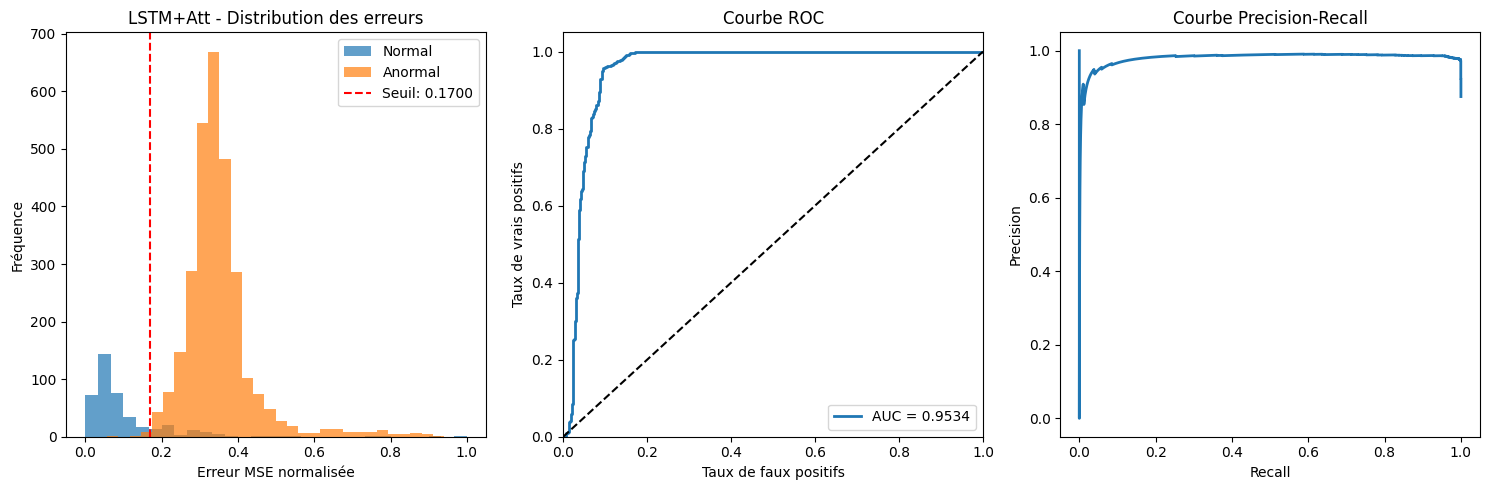

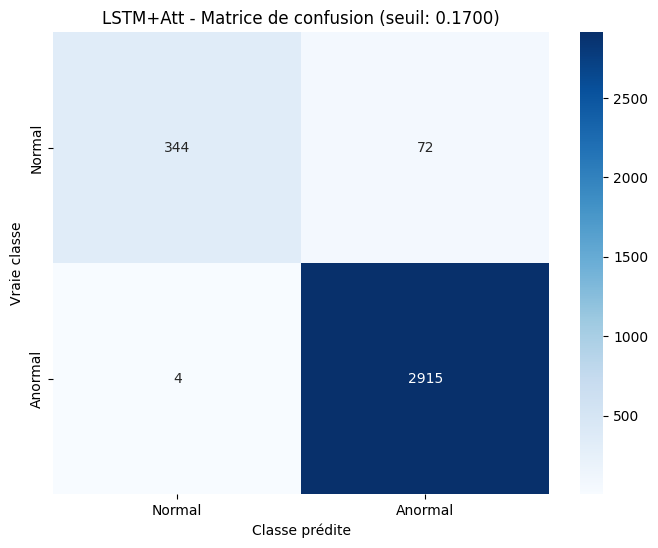

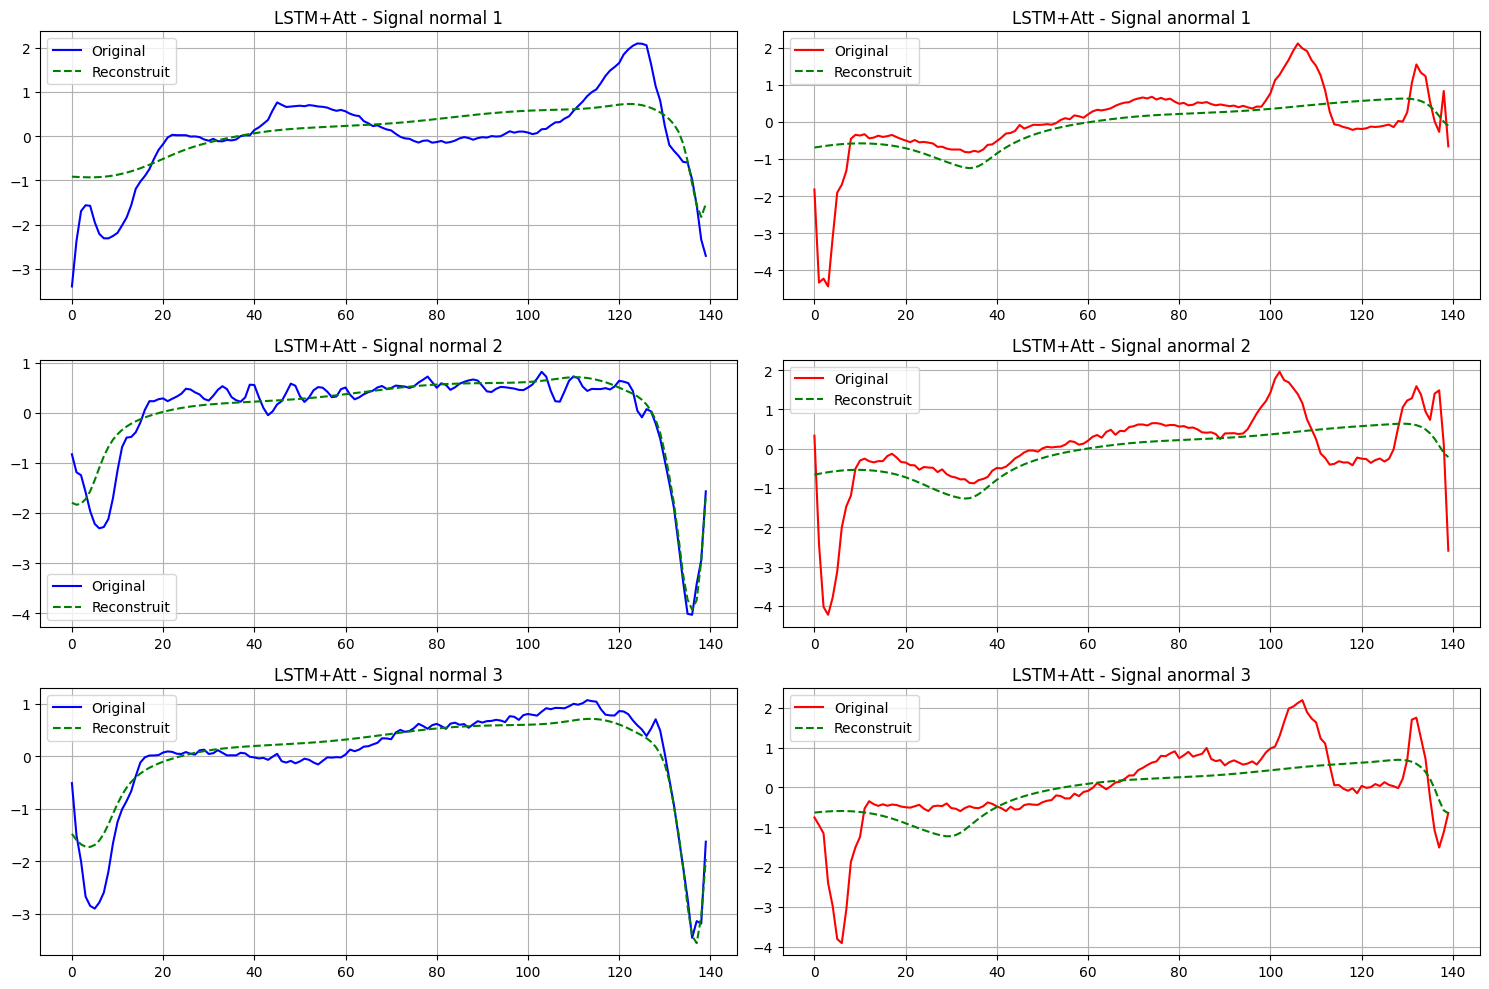

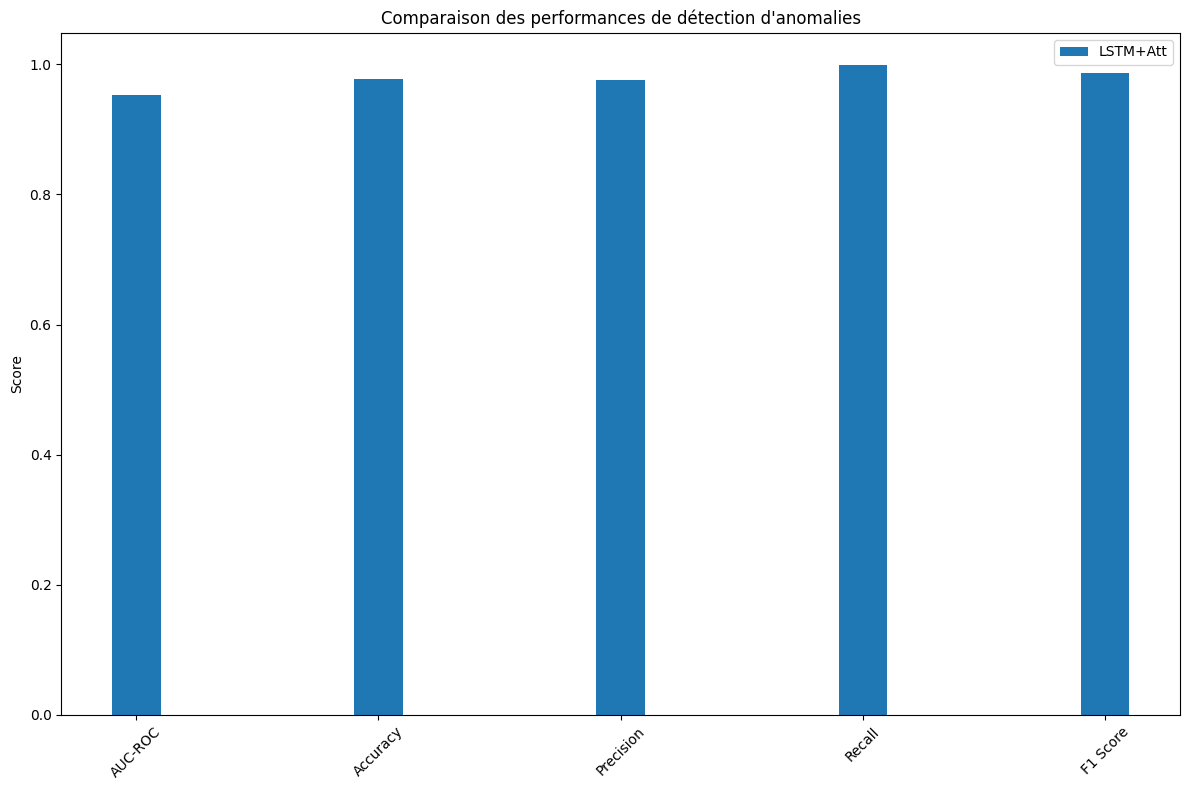


===== Tableau comparatif des modèles =====


TypeError: cannot unpack non-iterable NoneType object

In [ ]:
# Préparer les datasets et loaders pour l'évaluation
normal_valid_dset = ECGTestDataset(opt.normal_valid_path, is_normal=True)
testloader = torch.utils.data.DataLoader(
    normal_valid_dset, batch_size=1, shuffle=True, num_workers=opt.workers)

abnormal_valid_dset = ECGTestDataset(opt.patient_valid_path, is_normal=False)
validloader = torch.utils.data.DataLoader(
    abnormal_valid_dset, batch_size=1, shuffle=True, num_workers=opt.workers)

# Exécuter l'évaluation complète
print("\n\n======== ÉVALUATION FINALE DES MODÈLES ========\n")
results_eval, comparison_df = evaluate_anomaly_detection(
    models, testloader, validloader, device)

# Sauvegarder le tableau comparatif
comparison_df.to_csv("model_comparison.csv", index=False)

# Conclusion: Analyser les performances pour les trois objectifs
best_model_reconstruction = min(results.items(), key=lambda x: x[1]["losses"][-1])[0]
best_model_anomaly = max(results_eval.items(), key=lambda x: x[1]["f1_score"])[0]

print("\n\n======== CONCLUSION ========\n")
print(f"Meilleur modèle pour la reconstruction pure: {best_model_reconstruction}")
print(f"Meilleur modèle pour la détection d'anomalies: {best_model_anomaly}")

print("\nRésumé des performances de reconstruction:")
for name in results:
    final_loss = results[name]["losses"][-1]
    print(f"- {name}: Perte finale = {final_loss:.4f}")

print("\nRésumé des performances de détection d'anomalies:")
for name, metrics in results_eval.items():
    print(f"- {name}: AUC = {metrics['auc_roc']:.4f}, F1 Score = {metrics['f1_score']:.4f}")

# Si l'objectif est un espace latent structuré, les modèles avec KL sont préférables
if "KL" in best_model_anomaly:
    print("\nNote: Le meilleur modèle pour la détection d'anomalies utilise la divergence KL,")
    print("ce qui suggère un espace latent plus structuré qui peut être avantageux pour d'autres analyses.")

In [ ]:
# model = LSTMEncoder().to(device)
# criterion = loss_function
# optimizer = torch.optim.Adam(model.parameters(), lr=opt.lr)
# epochs = 50
# epoch_losses = []
# for epoch in range(epochs):
#     total_loss = 0
#     for batch in trainloader:
#         batch = batch.to(device)
#         optimizer.zero_grad()
#         output = model(batch)
#         loss = criterion(output, batch)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()

#     avg_loss = total_loss / len(trainloader.dataset)
#     epoch_losses.append(avg_loss)
#     print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

Epoch 1/50 - Loss: 129.7407
Epoch 2/50 - Loss: 92.0473
Epoch 3/50 - Loss: 82.9041
Epoch 4/50 - Loss: 78.4133
Epoch 5/50 - Loss: 75.7739
Epoch 6/50 - Loss: 74.0185
Epoch 7/50 - Loss: 57.9079
Epoch 8/50 - Loss: 43.7799
Epoch 9/50 - Loss: 46.2264
Epoch 10/50 - Loss: 42.7414
Epoch 11/50 - Loss: 48.9854
Epoch 12/50 - Loss: 40.9381
Epoch 13/50 - Loss: 38.4790
Epoch 14/50 - Loss: 38.0993
Epoch 15/50 - Loss: 36.1746
Epoch 16/50 - Loss: 35.4023
Epoch 17/50 - Loss: 34.7197
Epoch 18/50 - Loss: 34.6810
Epoch 19/50 - Loss: 35.3724
Epoch 20/50 - Loss: 35.7484
Epoch 21/50 - Loss: 32.8026
Epoch 22/50 - Loss: 31.2242
Epoch 23/50 - Loss: 31.2158
Epoch 24/50 - Loss: 29.3441
Epoch 25/50 - Loss: 29.4147
Epoch 26/50 - Loss: 31.7465
Epoch 27/50 - Loss: 30.7415
Epoch 28/50 - Loss: 28.1054
Epoch 29/50 - Loss: 28.9584
Epoch 30/50 - Loss: 28.1050
Epoch 31/50 - Loss: 26.9943
Epoch 32/50 - Loss: 28.7120
Epoch 33/50 - Loss: 25.4132
Epoch 34/50 - Loss: 24.6349
Epoch 35/50 - Loss: 24.2560
Epoch 36/50 - Loss: 24.5938


In [ ]:
# # Fonction de visualisation des reconstructions
# def plot_reconstruction(model, name, n_samples=5):
#     model.eval()
#     samples = next(iter(trainloader))[:n_samples].to(device)
#     print(samples.shape)
#     with torch.no_grad():
#         output = model(samples)
#         if isinstance(output, tuple):
#             output = output[0]

#     samples = samples.cpu().numpy()
#     output = output.cpu().numpy()
#     print(output.shape)
#     print(output)

#     plt.figure(figsize=(15, n_samples * 2))
#     for i in range(n_samples):
#         plt.subplot(n_samples, 2, 2 * i + 1)
#         plt.plot(samples[i], label="Original")
#         plt.title(f"{name} - Original Signal {i+1}")
#         plt.grid(True)
#         plt.subplot(n_samples, 2, 2 * i + 2)
#         plt.plot(output[i], label="Reconstruit", color="orange")
#         plt.title(f"{name} - Reconstruction {i+1}")
#         plt.grid(True)
#     plt.tight_layout()
#     plt.savefig(f"{name}_reconstructions.png")
#     plt.show()

torch.Size([5, 140])
(5, 140)
[[ 2.94218510e-02 -2.64412403e-01 -7.14142144e-01 -1.25135112e+00
  -1.77358723e+00 -2.16757607e+00 -2.35474896e+00 -2.32155132e+00
  -2.10830045e+00 -1.78752184e+00 -1.43372679e+00 -1.10077405e+00
  -8.12276006e-01 -5.70459485e-01 -3.69731575e-01 -2.03964949e-01
  -6.82452843e-02  4.14188951e-02  1.28543347e-01  1.96327806e-01
   2.47629881e-01  2.84910649e-01  3.10230315e-01  3.25313628e-01
   3.31656098e-01  3.30635220e-01  3.23585898e-01  3.11820686e-01
   2.96598762e-01  2.79070407e-01  2.60225028e-01  2.40863562e-01
   2.21598029e-01  2.02871561e-01  1.84988499e-01  1.68146014e-01
   1.52462065e-01  1.37998268e-01  1.24776974e-01  1.12793773e-01
   1.02026239e-01  9.24403667e-02  8.39948356e-02  7.66442716e-02
   7.03413337e-02  6.50384128e-02  6.06890321e-02  5.72485626e-02
   5.46749979e-02  5.29295653e-02  5.19770533e-02  5.17863333e-02
   5.23304939e-02  5.35872430e-02  5.55392504e-02  5.81743270e-02
   6.14861101e-02  6.54744208e-02  7.01458901e

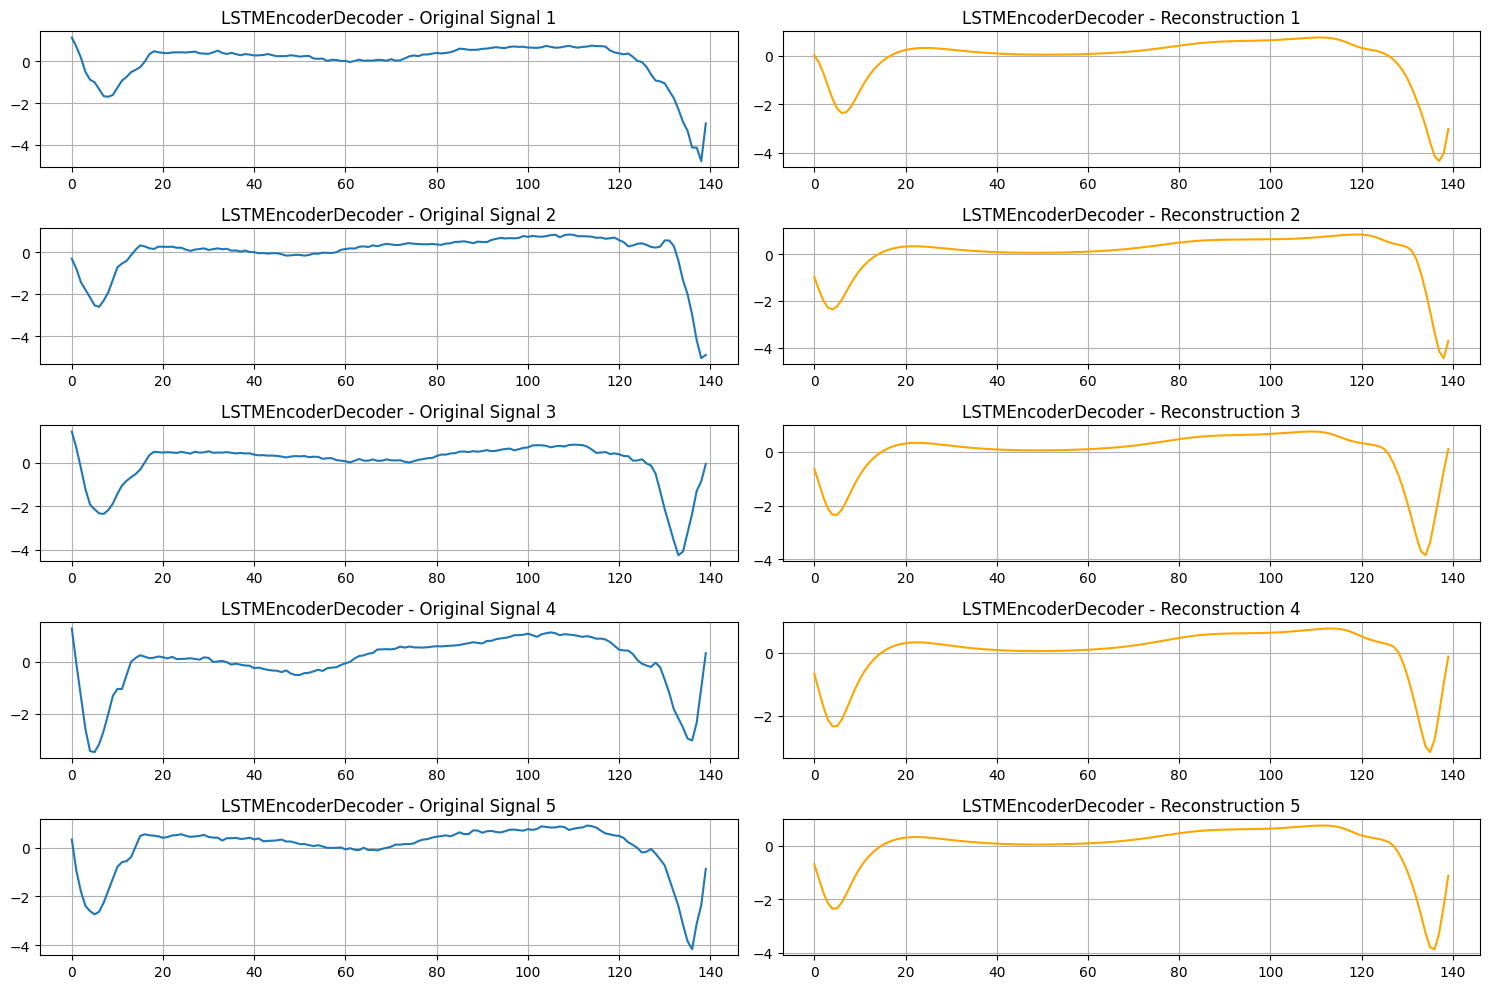

In [ ]:
# plot_reconstruction(model, "LSTMEncoderDecoder")

In [ ]:
# model = GRUEncoder().to(device)
# criterion = loss_function
# optimizer = torch.optim.Adam(model.parameters(), lr=opt.lr)
# epochs = 50
# epoch_losses = []
# for epoch in range(epochs):
#     total_loss = 0
#     for batch in trainloader:
#         batch = batch.to(device)
#         optimizer.zero_grad()
#         output = model(batch)
#         loss = criterion(output, batch)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()

#     avg_loss = total_loss / len(trainloader.dataset)
#     epoch_losses.append(avg_loss)
#     print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

Epoch 1/50 - Loss: 124.8054
Epoch 2/50 - Loss: 92.5308
Epoch 3/50 - Loss: 84.4766
Epoch 4/50 - Loss: 79.7505
Epoch 5/50 - Loss: 75.2175
Epoch 6/50 - Loss: 76.0339
Epoch 7/50 - Loss: 76.6465
Epoch 8/50 - Loss: 71.6260
Epoch 9/50 - Loss: 63.4057
Epoch 10/50 - Loss: 52.9079
Epoch 11/50 - Loss: 42.8628
Epoch 12/50 - Loss: 38.4716
Epoch 13/50 - Loss: 40.5393
Epoch 14/50 - Loss: 36.1875
Epoch 15/50 - Loss: 37.4699
Epoch 16/50 - Loss: 35.9607
Epoch 17/50 - Loss: 35.6093
Epoch 18/50 - Loss: 34.0068
Epoch 19/50 - Loss: 34.1690
Epoch 20/50 - Loss: 33.3651
Epoch 21/50 - Loss: 31.4111
Epoch 22/50 - Loss: 31.7871
Epoch 23/50 - Loss: 32.6736
Epoch 24/50 - Loss: 30.0749
Epoch 25/50 - Loss: 30.2002
Epoch 26/50 - Loss: 31.6197
Epoch 27/50 - Loss: 29.0173
Epoch 28/50 - Loss: 27.8526
Epoch 29/50 - Loss: 26.7111
Epoch 30/50 - Loss: 29.1211
Epoch 31/50 - Loss: 30.1563
Epoch 32/50 - Loss: 27.2170
Epoch 33/50 - Loss: 26.7480
Epoch 34/50 - Loss: 25.5666
Epoch 35/50 - Loss: 25.1139
Epoch 36/50 - Loss: 27.7016


torch.Size([5, 140])
(5, 140)
[[-1.02049494e+00 -1.35477233e+00 -1.67440319e+00 -1.90429890e+00
  -1.99050045e+00 -1.91987360e+00 -1.72335505e+00 -1.45714724e+00
  -1.17492652e+00 -9.11669433e-01 -6.82449222e-01 -4.89526600e-01
  -3.29599321e-01 -1.97895557e-01 -8.98286700e-02 -1.48484111e-03
   7.03346133e-02  1.28209800e-01  1.74225211e-01  2.10083783e-01
   2.37199873e-01  2.56775528e-01  2.69857049e-01  2.77377725e-01
   2.80187249e-01  2.79070437e-01  2.74756312e-01  2.67921120e-01
   2.59186208e-01  2.49113739e-01  2.38202095e-01  2.26882398e-01
   2.15517104e-01  2.04401135e-01  1.93765700e-01  1.83783710e-01
   1.74577132e-01  1.66224837e-01  1.58770531e-01  1.52230486e-01
   1.46600470e-01  1.41861856e-01  1.37986675e-01  1.34941652e-01
   1.32691339e-01  1.31200492e-01  1.30435750e-01  1.30366683e-01
   1.30966455e-01  1.32212043e-01  1.34084433e-01  1.36568189e-01
   1.39651343e-01  1.43324971e-01  1.47582620e-01  1.52419925e-01
   1.57834098e-01  1.63823396e-01  1.70386657e

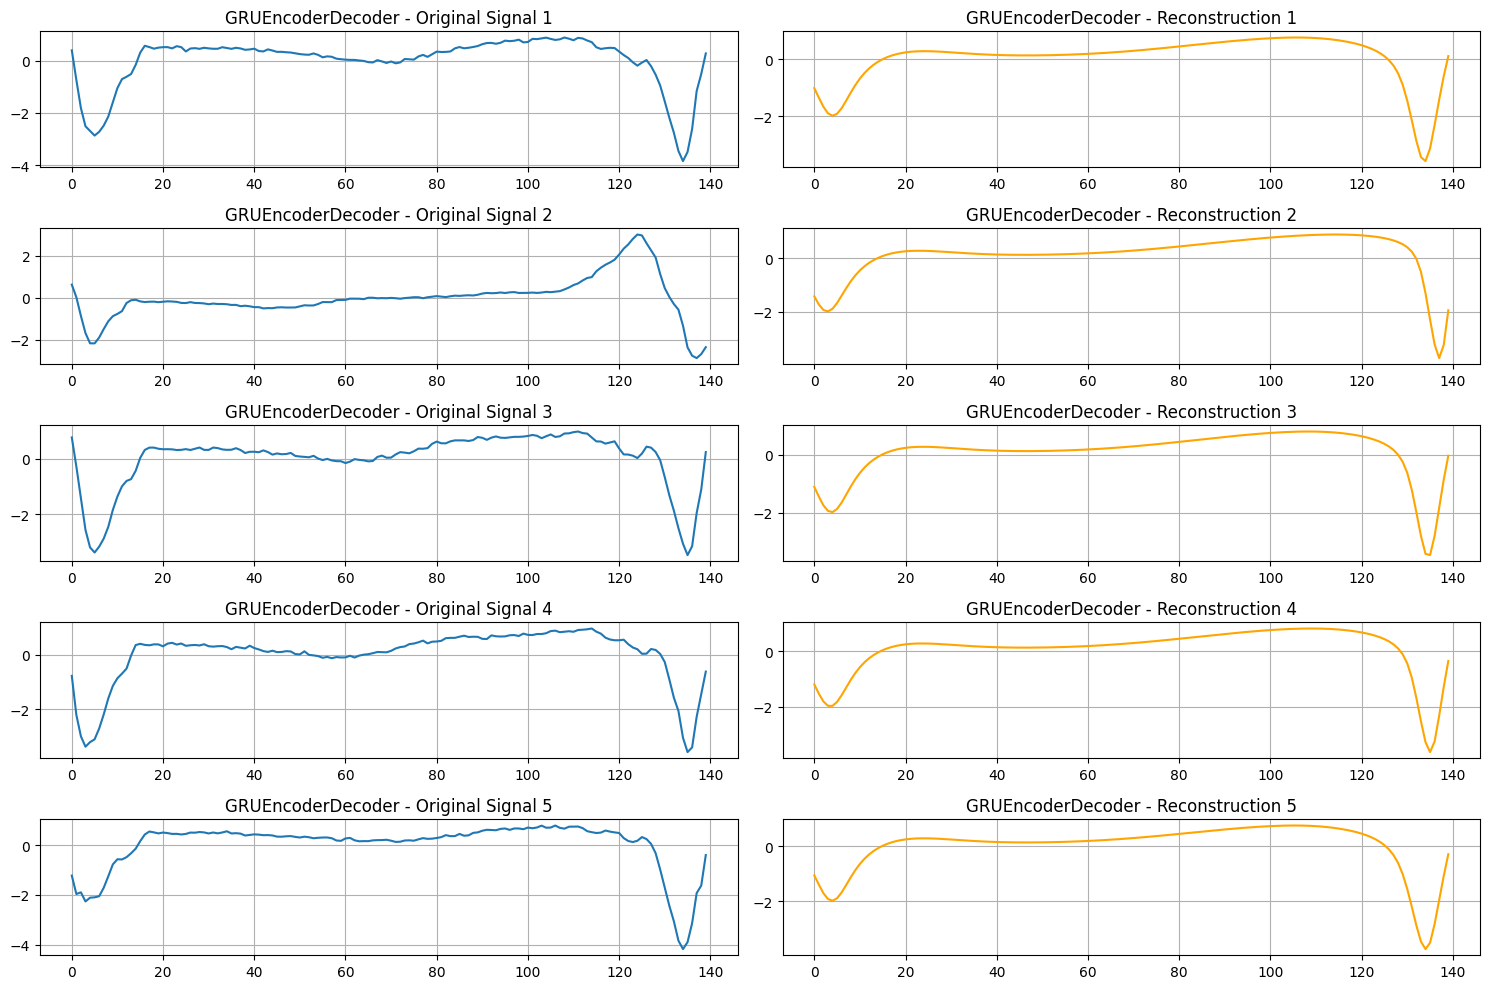

In [ ]:
# plot_reconstruction(model, "GRUEncoderDecoder")